In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import os
warnings.filterwarnings('ignore')


INPUT_FILE = os.path.join('../Master-Data/clean_food_data.csv')

df = pd.read_csv(INPUT_FILE, low_memory=False)

print(f'   Rows    : {len(df):,}')
print(f'   Columns : {list(df.columns)}')
df.head(3)

   Rows    : 47,495
   Columns : ['product_name', 'categories_tags', 'ingredients_text', 'nutriscore_score', 'energy_100g', 'fat_100g', 'saturated-fat_100g', 'carbohydrates_100g', 'sugars_100g', 'fiber_100g', 'proteins_100g', 'salt_100g']


,product_name,categories_tags,ingredients_text,nutriscore_score,energy_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g
0,Pinto Bean,en:asian-style-ready-meal,NaN,NaN,9.0,10.2,3.6,22.5,4.9,3.8,17.5,NaN
1,pasta,"en:beverages-and-beverages-preparations,en:bev...",NaN,5.0,697.1,6.4,1.3,20.0,1.9,0.8,6.7,0.0009
2,Eirn original curry Sauce,"en:plant-based-foods-and-beverages,en:plant-ba...",Wheat Flour Sugar Vegetable Fat D Curry Powder...,NaN,1724.0,18.0,8.2,57.2,29.6,1.2,5.2,4.7500


In [11]:
print('=== CATEGORIES_TAGS COLUMN INSPECTION ===')
print(f'\nNull values : {df["categories_tags"].isnull().sum():,}')
print(f'Unique values : {df["categories_tags"].nunique():,}')

print('\n--- 10 Random Raw Examples ---')
samples = df['categories_tags'].dropna().sample(10, random_state=42)
for i, val in enumerate(samples, 1):
    print(f'{i}. {val[:120]}')

print('   Format: comma-separated tags prefixed with "en:"')
print('   Example: en:snacks,en:sweet-snacks,en:biscuits')

=== CATEGORIES_TAGS COLUMN INSPECTION ===

Null values : 0
Unique values : 9,854

--- 10 Random Raw Examples ---
1. en:plant-based-foods-and-beverages,en:plant-based-foods,en:cereals-and-potatoes,en:breads
2. en:beverages
3. en:snacks,en:salty-snacks,en:popcorn,en:salted-popcorn
4. en:sandwiches,en:poultry-sandwiches,en:chicken-sandwiches
5. en:plant-based-foods-and-beverages,en:plant-based-foods,en:fruits-and-vegetables-based-foods,en:vegetables-based-foods,e
6. en:spaghetti-and-meatballs
7. en:plant-based-foods-and-beverages,en:plant-based-foods,en:fruits-and-vegetables-based-foods,en:legumes-and-their-produc
8. en:meals,en:microwave-meals
9. en:snacks,en:sweet-snacks,en:confectioneries,en:candies
10. en:snacks,en:salty-snacks,en:appetizers,en:chips-and-fries,en:crisps,en:corn-chips
   Format: comma-separated tags prefixed with "en:"
   Example: en:snacks,en:sweet-snacks,en:biscuits


## Parsing Category names

In [12]:
def parse_categories(cat_str):
    """
    Convert raw categories_tags string into a clean lowercase string.
    Input:  'en:snacks,en:sweet-snacks,en:biscuits'
    Output: 'snacks sweet-snacks biscuits'
    """
    if pd.isna(cat_str):
        return ''
    tags = [t.strip().lower().replace('en:', '') for t in str(cat_str).split(',')]
    return ' '.join(tags)

df['cat_str'] = df['categories_tags'].apply(parse_categories)

# Preview
print('Sample before vs after parsing:')
print(df[['categories_tags', 'cat_str']].head(5).to_string())

Sample before vs after parsing:
                                                                                                                         categories_tags                                                                                                              cat_str
0                                                                                                              en:asian-style-ready-meal                                                                                               asian-style-ready-meal
1                                                                                   en:beverages-and-beverages-preparations,en:beverages                                                                       beverages-and-beverages-preparations beverages
2              en:plant-based-foods-and-beverages,en:plant-based-foods,en:condiments,en:spices,en:curry-powder,en:powder,en:sauce-powder                 plant-based-foods-and-beverages plant-based-foods con

## 15 Categories

In [13]:
CATEGORY_RULES = [

    # Health / Protein First
    (
        'Protein Bars & Supplements',
        ['protein-bar', 'protein-powder', 'sports-nutrition',
         'whey', 'protein bar', 'protein-shake']
    ),
    (
        'Meat & Fish Snacks',
        ['jerky', 'meat-snack', 'biltong', 'beef-snack',
         'pepperoni-snack', 'dried-meat', 'meat-stick',
         'fish-snack', 'smoked-salmon']
    ),
    (
        'Nuts, Seeds & Dried Fruit',
        ['nut', 'seed', 'almond', 'cashew', 'peanut',
         'dried-fruit', 'trail-mix', 'raisin', 'pistachio',
         'walnut', 'pecan', 'hazelnut', 'sunflower-seed']
    ),
    (
        'Yogurt & Dairy Snacks',
        ['yogurt', 'yoghurt', 'fromage', 'quark',
         'kefir', 'dairy-dessert', 'dairy-snack']
    ),

    # ── Savoury Snacks ─────────────────────────────────────────
    (
        'Chips & Crisps',
        ['chips', 'crisps', 'corn-snack', 'tortilla-chip',
         'potato-chip', 'vegetable-chip', 'kale-chip',
         'beetroot-chip', 'veggie-straw', 'seaweed-snack',
         'puffed']
    ),
    (
        'Popcorn',
        ['popcorn', 'kettle-corn', 'caramel-popcorn',
         'popped-corn']
    ),
    (
        'Crackers & Savoury Biscuits',
        ['cracker', 'crispbread', 'breadstick', 'pretzel',
         'rusk', 'rice-cake', 'rice-cracker', 'corn-cake',
         'oatcake', 'matzo', 'savoury-biscuit']
    ),
    (
        'Cheese Snacks',
        ['cheese-snack', 'cheese-stick', 'cheese-puff',
         'cheese-crisp', 'string-cheese', 'cheese-bite']
    ),

    # Sweet Snacks
    (
        'Biscuits & Cookies',
        ['biscuit', 'cookie', 'wafer', 'shortbread',
         'digestive', 'bourbon']
    ),
    (
        'Chocolate & Candy',
        ['chocolate', 'candy', 'confectionery', 'gummies',
         'sweets', 'caramel', 'lollipop', 'marshmallow',
         'fudge', 'toffee', 'nougat', 'truffle']
    ),
    (
        'Cakes & Pastries',
        ['cake', 'pastry', 'muffin', 'brownie', 'cupcake',
         'tart', 'donut', 'doughnut', 'croissant', 'eclair',
         'pancake', 'waffle', 'scone', 'danish']
    ),
    (
        'Ice Cream & Frozen Snacks',
        ['ice-cream', 'frozen-dessert', 'gelato', 'sorbet',
         'popsicle', 'frozen-yogurt', 'ice-lolly']
    ),
    (
        'Sweet Spreads & Dips',
        ['jam', 'jelly', 'honey', 'chocolate-spread',
         'hazelnut-spread', 'peanut-butter', 'nut-butter',
         'fruit-spread', 'caramel-spread']
    ),

    #Bars & Fruits
    (
        'Granola, Bars & Cereals',
        ['granola', 'cereal-bar', 'energy-bar', 'muesli',
         'oat-bar', 'breakfast-cereal', 'flapjack',
         'breakfast-bar', 'rice-crispy-bar']
    ),
    (
        'Fruit Snacks',
        ['fruit-snack', 'fruit-leather', 'fruit-chip',
         'dried-apple', 'dried-mango', 'fruit-bar',
         'freeze-dried-fruit']
    ),
]

def assign_category(cat_str):
    """Return first matching category label, or 'Other Snacks'."""
    for label, keywords in CATEGORY_RULES:
        for kw in keywords:
            if kw in cat_str:
                return label
    return 'Other Snacks'

# Apply to every row
df['Primary_Category'] = df['cat_str'].apply(assign_category)

# Distribution check
cat_counts = df['Primary_Category'].value_counts()
other_pct  = (df['Primary_Category'] == 'Other Snacks').sum() / len(df) * 100

print('15 category buckets defined (expanded from 8)')
print(f'   Other Snacks : {other_pct:.1f}% (target: < 20%)')
print(f'   Status       : {"GOOD" if other_pct < 20 else "⚠Still high — check keywords"}')
print()
print(f'{"Category":<35} {"Count":>8}  {"% of Total":>10}')
print('-' * 58)
for cat, count in cat_counts.items():
    pct  = count / len(df) * 100
    flag = ' ← review' if cat == 'Other Snacks' and pct > 20 else ''
    print(f'{cat:<35} {count:>8,}  {pct:>9.3f}%{flag}')

15 category buckets defined (expanded from 8)
   Other Snacks : 63.6% (target: < 20%)
   Status       : ⚠Still high — check keywords

Category                               Count  % of Total
----------------------------------------------------------
Other Snacks                          30,199     63.584% ← review
Yogurt & Dairy Snacks                  3,924      8.262%
Nuts, Seeds & Dried Fruit              3,230      6.801%
Granola, Bars & Cereals                2,288      4.817%
Biscuits & Cookies                     1,776      3.739%
Chips & Crisps                         1,379      2.903%
Chocolate & Candy                      1,330      2.800%
Crackers & Savoury Biscuits            1,071      2.255%
Ice Cream & Frozen Snacks                671      1.413%
Sweet Spreads & Dips                     655      1.379%
Cakes & Pastries                         402      0.846%
Protein Bars & Supplements               255      0.537%
Meat & Fish Snacks                       158      0.333%


## Handle Unmatched Products
Products that didn't match any keyword are assigned **'Other Snacks'** by the function above.
Let's verify and inspect what's in that bucket.

In [14]:
other = df[df['Primary_Category'] == 'Other Snacks']

print(f'Products in Other Snacks : {len(other):,} ({len(other)/len(df)*100:.1f}%)')
print('\nSample of unmatched products:')
print(other[['product_name', 'categories_tags']].sample(min(8, len(other)), random_state=42).to_string())
print('\nUnmatched products assigned to Other Snacks')

Products in Other Snacks : 30,199 (63.6%)

Sample of unmatched products:
                                            product_name                                                                                                                                                                                                               categories_tags
5071                                 Basen balance musli                                                                                                                 en:plant-based-foods-and-beverages,en:plant-based-foods,en:cereals-and-potatoes,en:cereals-and-their-products
4984                                       Lil crunchies                                                                                                                                                                                                                 en:baby-foods
38032                            Soft white dinner rolls                                  

In [15]:
cat_counts = df['Primary_Category'].value_counts()
cat_pct    = (cat_counts / len(df) * 100).round(1)

print('=== CATEGORY DISTRIBUTION VALIDATION ===')
print(f'{"Category":<35} {"Count":>8}  {"% of Total":>10}  {"Valid?":>8}')
print('-' * 70)

all_valid = True
for cat in cat_counts.index:
    count = cat_counts[cat]
    pct   = cat_pct[cat]
    valid = 'good' if pct <= 60 else ' OVER 60%'
    if pct > 60:
        all_valid = False
    print(f'{cat:<35} {count:>8,}  {pct:>9.1f}%  {valid:>8}')

print('-' * 70)
print(f'\nAll categories under 60%? {"YES" if all_valid else " NO — Review rules"}')
print(f'Total distinct categories : {df["Primary_Category"].nunique()}')
print(f'\nValidation done')

=== CATEGORY DISTRIBUTION VALIDATION ===
Category                               Count  % of Total    Valid?
----------------------------------------------------------------------
Other Snacks                          30,199       63.6%   OVER 60%
Yogurt & Dairy Snacks                  3,924        8.3%      good
Nuts, Seeds & Dried Fruit              3,230        6.8%      good
Granola, Bars & Cereals                2,288        4.8%      good
Biscuits & Cookies                     1,776        3.7%      good
Chips & Crisps                         1,379        2.9%      good
Chocolate & Candy                      1,330        2.8%      good
Crackers & Savoury Biscuits            1,071        2.3%      good
Ice Cream & Frozen Snacks                671        1.4%      good
Sweet Spreads & Dips                     655        1.4%      good
Cakes & Pastries                         402        0.8%      good
Protein Bars & Supplements               255        0.5%      good
Meat & Fish Snac

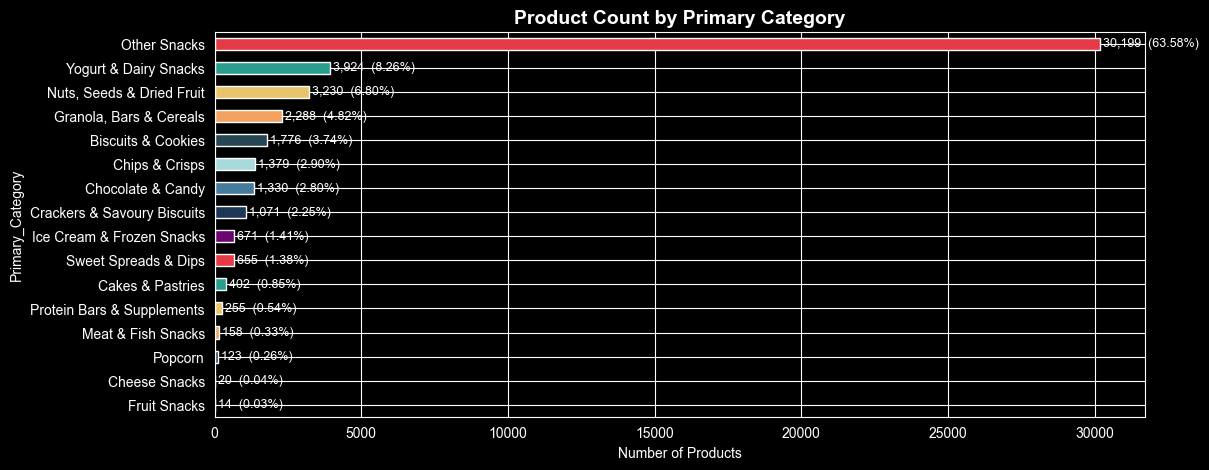

In [16]:
# Category Distribution Bar Chart 
fig, ax = plt.subplots(figsize=(12, 5))

colors = ['#E63946','#2A9D8F','#E9C46A','#F4A261',
          '#264653','#A8DADC','#457B9D','#1D3557','#6A0572']

cat_counts.plot(kind='barh', ax=ax,
                color=colors[:len(cat_counts)],
                edgecolor='white')

ax.set_title('Product Count by Primary Category',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Products')
ax.invert_yaxis()

for i, (cat, val) in enumerate(cat_counts.items()):
    pct = val / len(df) * 100
    ax.text(val + 100, i, f'{val:,}  ({pct:.2f}%)', va='center', fontsize=9)


In [17]:
# Drop helper column before saving
df_export = df.drop(columns=['cat_str'])

OUTPUT_FILE = ('../Master-Data/categorized_food_data.csv')
df_export.to_csv(OUTPUT_FILE, index=False)

print(f'Categorized dataset exported!')
print(f'   File    : {OUTPUT_FILE}')
print(f'   Rows    : {len(df_export):,}')
print(f'   Columns : {list(df_export.columns)}')

Categorized dataset exported!
   File    : ../Master-Data/categorized_food_data.csv
   Rows    : 47,495
   Columns : ['product_name', 'categories_tags', 'ingredients_text', 'nutriscore_score', 'energy_100g', 'fat_100g', 'saturated-fat_100g', 'carbohydrates_100g', 'sugars_100g', 'fiber_100g', 'proteins_100g', 'salt_100g', 'Primary_Category']
